In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv(r"C:\Users\>>>\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


if 'Id' in df.columns:
    df = df.drop(columns=['Id'])


import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)


df.fillna(df.mean(), inplace=True)


df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
"""Data Splitting
After data preprocessing, the dataset was split into independent variables and the target variable.

TRAINING: used for the model to learn patterns from the data.

TESTING: used to evaluate the model’s performance on data it has not seen before."""

'Data Splitting\nAfter data preprocessing, the dataset was split into independent variables and the target variable.\n\nTRAINING: used for the model to learn patterns from the data.\n\nTESTING: used to evaluate the model’s performance on data it has not seen before.'

In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
"""Exploratory Data Analysis (EDA)
Exploratory data analysis was conducted to better understand the distribution of variables and identify possible patterns.

Graphs such as histograms, boxplots, and correlation plots were used to observe the behavior of the data.

From these visualizations, it was possible to identify relationships between some variables and the target variable, as well as observe the presence of potential outliers and skewed distributions.

Class Distribution

This graph shows the distribution of classes in the target variable (Outcome), indicating the number of individuals with and without diabetes in the dataset. This analysis is important to
check whether the classes are balanced, a factor that can directly influence the performance of the machine learning model."""

'Exploratory Data Analysis (EDA)\nExploratory data analysis was conducted to better understand the distribution of variables and identify possible patterns.\n\nGraphs such as histograms, boxplots, and correlation plots were used to observe the behavior of the data.\n\nFrom these visualizations, it was possible to identify relationships between some variables and the target variable, as well as observe the presence of potential outliers and skewed distributions.\n\nClass Distribution\n\nThis graph shows the distribution of classes in the target variable (Outcome), indicating the number of individuals with and without diabetes in the dataset. This analysis is important to\ncheck whether the classes are balanced, a factor that can directly influence the performance of the machine learning model.'

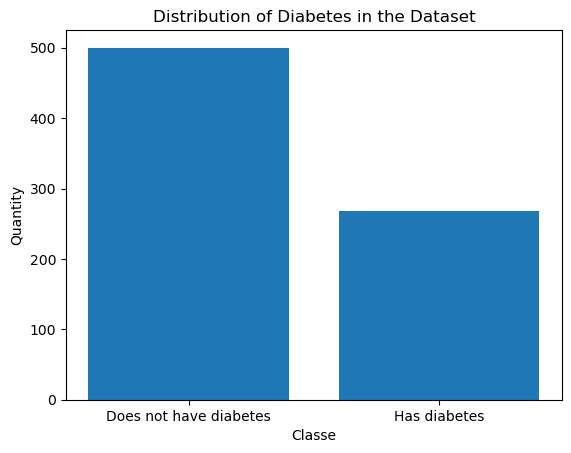

In [10]:
contagem = df['Outcome'].value_counts()

plt.figure()
plt.bar(["Does not have diabetes", "Has diabetes"], contagem)

plt.title('Distribution of Diabetes in the Dataset')
plt.ylabel('Quantity')
plt.xlabel('Classe')

plt.show()

In [11]:
"""Correlation Matrix

The correlation matrix shows the degree of relationship between the variables in the dataset. Through this analysis, it is possible to identify which attributes have stronger associations with each other and with the target variable. 
This visualization helps in understanding the data and identifying potential patterns that may be relevant for the model."""

'Correlation Matrix\n\nThe correlation matrix shows the degree of relationship between the variables in the dataset. Through this analysis, it is possible to identify which attributes have stronger associations with each other and with the target variable. \nThis visualization helps in understanding the data and identifying potential patterns that may be relevant for the model.'

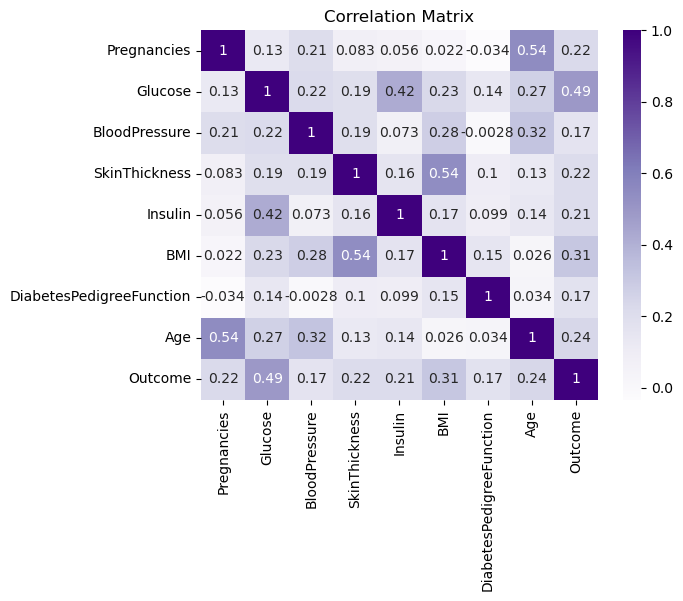

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='Purples')

plt.title('Correlation Matrix')
plt.show()

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Pipeline: Scaling + KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hyperparameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# GridSearch with pipeline
grid_com_scale = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy'
)

# Train
grid_com_scale.fit(X_train, y_train)

# Best results
print("Best Parameters:", grid_com_scale.best_params_)
print("Best CV Score:", grid_com_scale.best_score_)

# Evaluate on test set
test_score = grid_com_scale.score(X_test, y_test)
print("Test Accuracy:", test_score)

Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Best CV Score: 0.7589988841064881
Test Accuracy: 0.7272727272727273


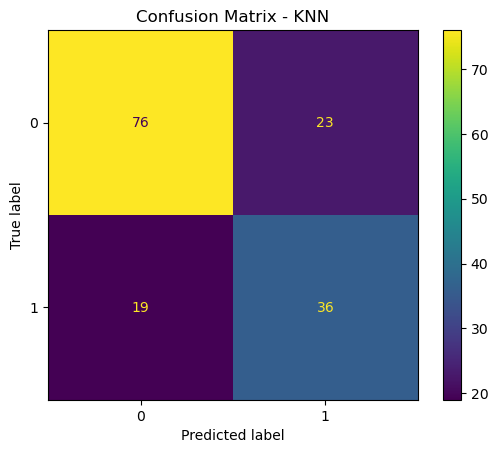

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = grid_com_scale.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - KNN")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.77      0.78        99
           1       0.61      0.65      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



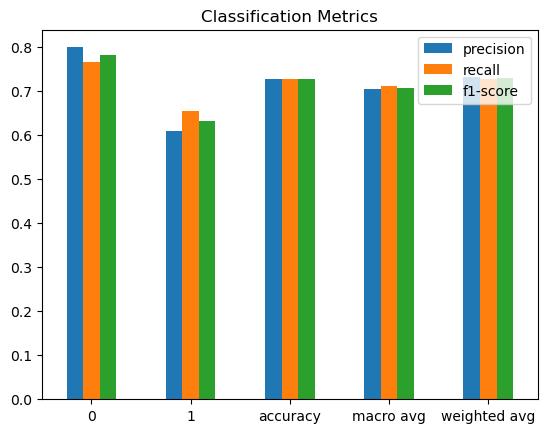

In [17]:
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title("Classification Metrics")
plt.xticks(rotation=0)
plt.show()

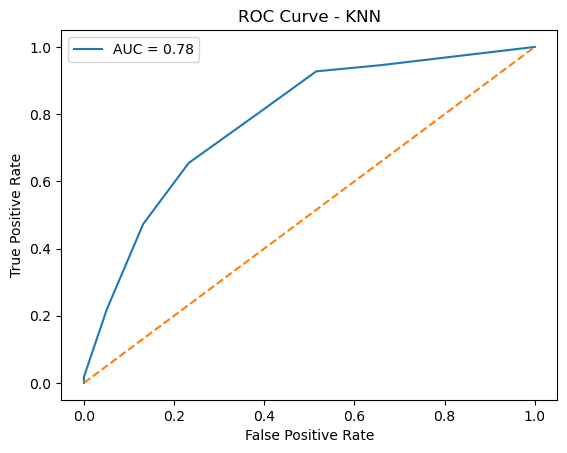

In [18]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob = grid_com_scale.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

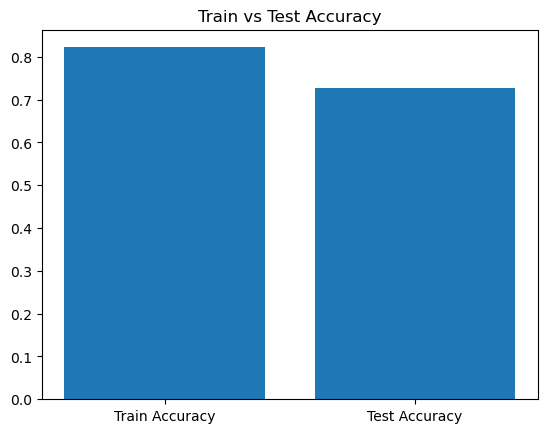

In [19]:
train_acc = grid_com_scale.score(X_train, y_train)
test_acc = grid_com_scale.score(X_test, y_test)

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.title("Train vs Test Accuracy")
plt.show()